In [1]:
import manim as mn
from manim import *
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

config.media_width = "75%"
config.verbosity = "WARNING"

print(mn.__version__)

0.20.1


In [ ]:
%%manim -qh DopplerEffect_rus

current_frame = 0
class DopplerEffect_rus(Scene):
    
    def construct(self):
        
        source = Dot(point=LEFT*2.5)
        waves = VGroup()

        observer = Dot(point=DOWN*0.5, color=GREEN)

        
        def addwavefront(mob,dt):
            global current_frame
            wavefront=Circle(
                radius=0.01,
                color=YELLOW,
                stroke_width=1.5,
                arc_center=source.get_center()
            ) 
            current_frame += 1
            if current_frame%8 == 0:
                waves.add(wavefront)
            return current_frame

        def expandwaves(mob, dt):
            for wavefront in waves:
                wavefront.scale_to_fit_width(wavefront.width + 0.1)
                wavefront.set_stroke(opacity = 1 - wavefront.width/20)
                if (1 - wavefront.width/20) == 0:
                    waves.remove(wavefront)
    

        waves.add_updater(addwavefront)
        waves.add_updater(expandwaves)

        self.add(source)
        self.add(observer)
        self.add(waves)

        self.play(
                source.animate.shift(RIGHT*5), rate_func=linear, run_time=8
        )

        waves.remove_updater(addwavefront)

Manim Community v0.20.1

12


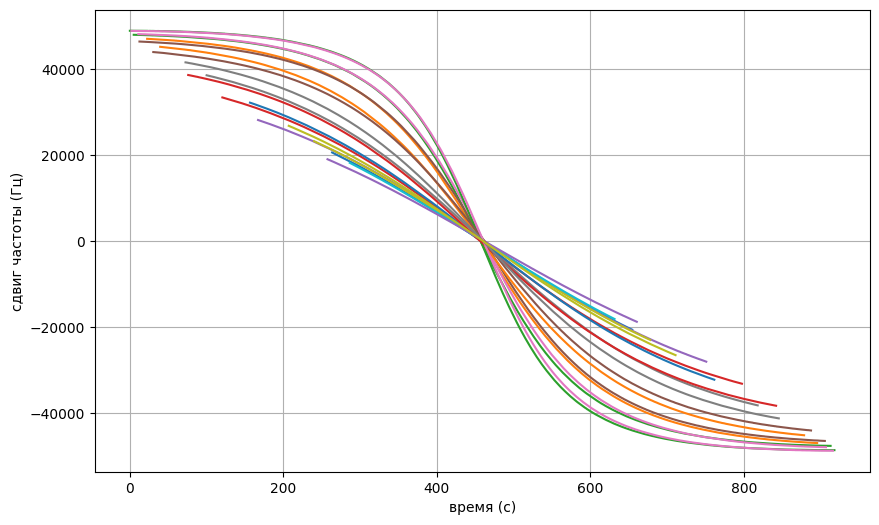

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
f_center = 2.2e9
curves = []
for i in range(1, 20):
    data = pd.read_csv(f"doppler_data/{i}")
    time = data["Time(s)"]
    signal = data["Frequency(Hz)"] - f_center
    curves.append((time, signal))

longest_curve = max(curves, key=lambda x: len(x[0]))
longest_curve_index = max(range(len(curves)), key=lambda idx: len(curves[idx][0]))
print(longest_curve_index)

time = longest_curve[0]

aligned_curves = []
for time, signal in curves:
    diff = -(len(time) - len(longest_curve[0]))/2
    times = []
    for t in time:
        times.append(t + diff)
    aligned_curves.append((times, signal))

plt.figure(figsize=(10, 6))
for i, (time, signal) in enumerate(aligned_curves):
    plt.plot(time, signal, label=f"Кривая {i+1}")
plt.xlabel("время (с)")
plt.ylabel("сдвиг частоты (Гц)")
plt.grid()
plt.show()

In [ ]:
%%manim -qh DopplerSlide_rus

import pandas as pd
import numpy as np

class DopplerSlide_rus(Scene):
    def construct(self):
        f_center = 2.2e9
        curves = []
        for i in range(1, 20):
            data = pd.read_csv(f"doppler_data/{i}")
            time = data["Time(s)"]
            signal = data["Frequency(Hz)"] - f_center
            curves.append((time.values, signal.values))
        
        longest_curve_idx = 12
        longest_curve = curves[longest_curve_idx]
        
        aligned_curves = []
        for time_arr, signal_arr in curves:
            diff = -(len(time_arr) - len(longest_curve[0])) / 2
            aligned_curves.append((time_arr + diff, signal_arr))
            
        main_time, main_signal = aligned_curves[longest_curve_idx]

        axes = Axes(
            x_range=[min(main_time), max(main_time), 100],
            y_range=[min(main_signal)-5000, max(main_signal)+5000, 10000],
            x_length=10,
            y_length=6,
            axis_config={"color": WHITE}
        )
        axes_labels = axes.get_axis_labels(
            x_label=Text("Время (с)", font_size=24), 
            y_label=Text("Сдвиг частоты (Гц)", font_size=24)
        )

        earth = Circle(radius=10, color=BLUE, fill_opacity=0.1)
        earth.move_to(DOWN * 12)
        
        observer = SVGMobject("ant.svg").scale(0.5).set_color(WHITE)
        observer.move_to(earth.get_top())
        obs_label = Text("Наблюдатель", color=WHITE, font_size=20).next_to(observer, DOWN, buff=0.2)
        
        orbit = Arc(
            radius=14, 
            angle=PI/3, 
            start_angle=PI/2 - PI/6, 
            arc_center=earth.get_center(), 
            color=DARK_GRAY
        )
        
        main_group = VGroup(earth, observer, obs_label, orbit)
        main_group.scale(0.85).shift(UP * 1.5)
        
        satellite = ImageMobject("satellite.png").scale(0.1 * 0.85)
        satellite.rotate(PI/10)
        satellite.current_angle = 0
        
        p_tracker = ValueTracker(0.0)
        
        def update_satellite(mob):
            p = p_tracker.get_value()
            p1 = max(0, p - 0.001)
            p2 = min(1, p + 0.001)
            tangent_vec = orbit.point_from_proportion(p2) - orbit.point_from_proportion(p1)
            target_angle = angle_of_vector(tangent_vec)
            
            mob.rotate(target_angle - mob.current_angle)
            mob.current_angle = target_angle
            
            mob.move_to(orbit.point_from_proportion(p))
            
        satellite.add_updater(update_satellite)
        
        rf_group = VGroup()
        def update_wave(mob):
            p = p_tracker.get_value()
            sat_pos = orbit.point_from_proportion(p)
            freq = 8 + 17 / (1 + np.exp(10 * (p - 0.5)))

            if p < 0.5:
                col = interpolate_color(BLUE, ORANGE, p * 2)
            else:
                col = interpolate_color(ORANGE, RED, (p - 0.5) * 2)

            link_line = Line(observer.get_center(), sat_pos)
            phase = 60 * ( 1 / (1 + np.exp(10 * (p - 0.5)+1)))

            new_wave = FunctionGraph(
                lambda x: 0.1 * np.sin(freq * x - phase), 
                x_range=[0, max(0.01, link_line.get_length())],
                color=col
            )

            new_wave.rotate(link_line.get_angle(), about_point=ORIGIN)
            new_wave.shift(observer.get_center())
            
            mob.become(new_wave)

        rf_group.add_updater(update_wave)
        
        self.add(earth, obs_label, orbit, rf_group, satellite, observer)
        
        axes_group = VGroup(axes, axes_labels).scale(0.4).to_corner(DL).shift(UP * 0.5)
        self.add(axes_group)
        
        graph = VMobject().set_color(YELLOW)
        
        def update_graph(mob):
            p = p_tracker.get_value()
            current_idx = int(p * len(main_time))
            if current_idx < 2:
                mob.set_points_as_corners([axes.c2p(main_time[0], main_signal[0]), axes.c2p(main_time[0], main_signal[0])])
                return
            
            x_vals = main_time[:current_idx]
            y_vals = main_signal[:current_idx]
            
            pts = [axes.c2p(x, y) for x, y in zip(x_vals, y_vals)]
            mob.set_points_as_corners(pts)
            
        graph.add_updater(update_graph)
        axes_group.add(graph)
        
        self.play(p_tracker.animate.set_value(1.0), run_time=10, rate_func=linear)
        
        graph.remove_updater(update_graph)
        rf_group.remove_updater(update_wave)
        
        self.play(
            FadeOut(earth, observer, obs_label, orbit, satellite, rf_group),
            axes_group.animate.scale(1/0.33).move_to(ORIGIN),
            run_time=1
        )
        
        new_curves = []
        for i in range(15):
            if i != longest_curve_idx:
                t, s = aligned_curves[i]
                c = VMobject().set_color(random_bright_color())
                pts = [axes.c2p(x, y) for x, y in zip(t, s)]
                c.set_points_as_corners(pts)
                new_curves.append(c)
                
        for c in new_curves:
            self.play(FadeIn(c), run_time=0.3)
            
        self.wait(4)

Manim Community v0.20.1

# Сцена 4

In [ ]:
%%manim -qh FilteringScene_rus
import random

random.seed(42)

class FilteringScene_rus(Scene):
    def construct(self):
        num_dots_initial = 1500
        
        dots = VGroup(*[Dot(radius=0.04, color=WHITE) for _ in range(num_dots_initial)])
        dots.arrange_in_grid(rows=30, cols=50, buff=0.1)
        dots.move_to(LEFT * 2)
        
        filters_heading = Text("Фильтры:", font_size=36, color=WHITE)
        filters_heading.to_edge(UP).shift(DOWN * 0.5 + RIGHT * 3.5)
        self.add(filters_heading)
        
        filter_list = VGroup()
        
        counter_val = ValueTracker(15000)
        
        counter_label = Text("Кандидаты: ", font_size=36)
        counter_num = Integer(15000, font_size=36)
        counter_num.add_updater(lambda m: m.set_value(counter_val.get_value()))
        
        counter_group = VGroup(counter_label, counter_num).arrange(RIGHT, buff=0.2)

        counter_group.next_to(dots, DOWN, buff=0.5)
        
        def update_label(m):
            m.arrange(RIGHT, buff=0.2)
            m.next_to(dots, DOWN, buff=0.5)
            
        counter_group.add_updater(update_label)
        
        self.add(dots, counter_group)
        self.wait(1)

        def apply_filter(step_name, new_real_count, run_time=1.5, rows=None, buff=0.1):
            nonlocal dots
            new_dot_count = int(new_real_count / 10)
            
            if new_dot_count >= len(dots.submobjects):
                return

            new_text = Text(step_name, font_size=28, color=YELLOW)
            if len(filter_list) == 0:
                new_text.next_to(filters_heading, DOWN, aligned_edge=LEFT, buff=0.4)
            else:
                new_text.next_to(filter_list[-1], DOWN, aligned_edge=LEFT, buff=0.4)
            
            self.play(FadeIn(new_text), run_time=run_time*0.5)
            filter_list.add(new_text)

            is_image = isinstance(dots.submobjects[0], ImageMobject)

            self.remove(dots)

            if is_image:
                dots_to_keep = Group(*dots.submobjects[:new_dot_count])
                dots_to_drop = Group(*dots.submobjects[new_dot_count:])

                red_icons = Group(*[ImageMobject("saticonred.png").replace(icon) for icon in dots_to_drop])

                self.add(dots_to_keep, red_icons)
                dots_to_drop = red_icons
            else:
                dots_to_keep = VGroup(*dots.submobjects[:new_dot_count])
                dots_to_drop = VGroup(*dots.submobjects[new_dot_count:])

                self.add(dots_to_keep, dots_to_drop)

                self.play(
                    dots_to_drop.animate.set_color(RED),
                    run_time=run_time*0.2
                )

            dots_to_keep.generate_target()
            
            if rows is not None:
                dots_to_keep.target.arrange_in_grid(rows=rows, buff=buff)
            else:
                dots_to_keep.target.arrange_in_grid(buff=buff)
                
            dots_to_keep.target.move_to(LEFT * 2)

            self.play(
                dots_to_drop.animate.scale(0.01),
                FadeOut(dots_to_drop),
                counter_val.animate.set_value(new_real_count),
                MoveToTarget(dots_to_keep),
                run_time=run_time*0.7
            )
            
            self.remove(dots_to_drop)
            dots = dots_to_keep

        apply_filter("1. Мегасозвездия", 5000, 2)

        saticons = Group(*[ImageMobject("saticon.png").scale(0.04).move_to(dot.get_center()) for dot in dots])
        self.play(FadeOut(dots, run_time=0.5), FadeIn(saticons, run_time=0.5))
        dots = saticons

        apply_filter("2. Спутники на ВЭО", 4900, 1.5)

        apply_filter("3. Геостационарные", 4000, 1.5)

        apply_filter("4. Видимость", 300, 2)

        dots.generate_target()
        for icon in dots.target.submobjects:
            icon.scale(4)
        dots.target.arrange_in_grid(buff=0.4)
        dots.target.move_to(LEFT * 2)
        self.play(MoveToTarget(dots), run_time=1)

        apply_filter("5. Доплеровский сдвиг", 50, 1.5, rows=1, buff=0.5)

        self.wait(2)

Manim Community v0.20.1

In [ ]:
%%manim -qh PropagationScene_rus

class PropagationScene_rus(Scene):
    def construct(self):
        earth = Circle(radius=2, color=BLUE, fill_opacity=0.2).shift(DOWN * 3 + LEFT * 3)
        earth_center = earth.get_center()
        earth_label = Text("Земля", font_size=20, color=BLUE).move_to(earth_center)
        
        orbit = Arc(radius=6, angle=PI/2, start_angle=0, arc_center=earth_center, color=DARK_GRAY)
        
        self.play(FadeIn(earth), FadeIn(earth_label), Create(orbit), run_time=1)
        
        t0_prop = 0.15
        sat_pos = orbit.point_from_proportion(t0_prop)

        sat_icon = ImageMobject("saticon.png").scale(0.12).move_to(sat_pos).set_z_index(10)
        
        r_vec = Arrow(earth_center, sat_pos, buff=0, color=BLUE, max_tip_length_to_length_ratio=0.08)

        p1 = orbit.point_from_proportion(t0_prop - 0.01)
        p2 = orbit.point_from_proportion(t0_prop + 0.01)
        tangent = normalize(p2 - p1)
        v_vec = Arrow(sat_pos, sat_pos + tangent * 2, buff=0, color=RED, max_tip_length_to_length_ratio=0.15)
        
        sgp4_text = Text("1. SGP4 (Долго)", color=YELLOW, font_size=24).to_corner(UL)
        t0_label = MathTex("t_0").next_to(sat_icon, DR, buff=0.1)
        
        self.play(FadeIn(sat_icon), Write(sgp4_text), FadeIn(t0_label), run_time=0.8)

        loading_indicator = VGroup(
            Circle(radius=0.15, color=DARK_GRAY, stroke_width=4),
            Arc(radius=0.15, start_angle=PI/2, angle=PI, color=YELLOW, stroke_width=4)
        ).next_to(sgp4_text, RIGHT)
        
        self.play(FadeIn(loading_indicator), run_time=0.2)
        self.play(Rotate(loading_indicator, angle=-8*PI, about_point=loading_indicator.get_center()), run_time=2.5, rate_func=linear)
        self.play(FadeOut(loading_indicator), run_time=0.2)
        
        self.play(GrowArrow(r_vec), GrowArrow(v_vec), run_time=1)
        
        fg_text = Text("2. F&G Пропагация", color=GREEN, font_size=24).next_to(sgp4_text, DOWN, aligned_edge=LEFT)
        fg_formula = MathTex(r"\mathbf{r}(t + \Delta t) = f\,\mathbf{r}(t) + g\,\mathbf{v}(t)", font_size=32).next_to(fg_text, DOWN, aligned_edge=LEFT)
        
        time_text = Text("Время: + 0.0 мин", font_size=24).to_corner(UR)
        
        self.play(Write(fg_text), Write(fg_formula), FadeIn(time_text), run_time=1)
        
        steps = 10
        mins_per_step = 1.5

        t0_dot = Dot(sat_pos, radius=0.05, color=YELLOW)
        self.add(t0_dot)
        
        for i in range(1, steps + 1):
            next_prop = t0_prop + (0.8 - t0_prop) * (i / steps)
            next_pos = orbit.point_from_proportion(next_prop)
            
            np1 = orbit.point_from_proportion(max(0, next_prop - 0.01))
            np2 = orbit.point_from_proportion(min(1, next_prop + 0.01))
            new_tangent = normalize(np2 - np1)
            
            new_r_vec = Arrow(earth_center, next_pos, buff=0, color=BLUE, max_tip_length_to_length_ratio=0.08)
            new_v_vec = Arrow(next_pos, next_pos + new_tangent * 2.5, buff=0, color=RED, max_tip_length_to_length_ratio=0.15)
            
            new_time_text = Text(f"Время: + {i * mins_per_step:.1f} мин", font_size=24).to_corner(UR)
            trace_dot = Dot(next_pos, radius=0.05, color=GREEN)

            ti_label = MathTex(f"t_{{{i}}}").scale(0.7).next_to(next_pos, DR, buff=0.2)
            
            self.play(
                Transform(r_vec, new_r_vec),
                Transform(v_vec, new_v_vec),
                sat_icon.animate.move_to(next_pos),
                Transform(time_text, new_time_text),
                FadeIn(trace_dot),
                FadeIn(ti_label),
                run_time=0.15
            )
            
        self.wait(1)

Manim Community v0.20.1

In [ ]:
%%manim -qh DopplerMatchingScene_rus

import pandas as pd
import numpy as np

class DopplerMatchingScene_rus(Scene):
    def construct(self):
        f_center = 2.2e9

        file_ids = [12, 2, 5, 8]
        data_dict = {}
        max_time = 0
        for fid in file_ids:
            df = pd.read_csv(f"doppler_data/{fid}")
            t = df["Time(s)"].values
            t = t - t[0]
            s = df["Frequency(Hz)"].values - f_center
            s = s - np.mean(s)
            data_dict[fid] = (t, s)
            if t[-1] > max_time:
                max_time = t[-1]

        x_upper = int(np.ceil(max_time / 100.0)) * 100
        axes = Axes(
            x_range=[0, x_upper, 100],
            y_range=[-40000, 40000, 20000],
            x_length=10,
            y_length=5,
            axis_config={"color": WHITE}
        ).shift(UP * 0.5)
        
        x_label = Text("Время (с)", font_size=20).next_to(axes.x_axis, RIGHT, buff=0.2)
        y_label = Text("Доплеровский сдвиг (Гц)", font_size=20).next_to(axes.y_axis, LEFT, buff=0.2).rotate(PI/2)
        
        self.play(Create(axes), Write(x_label), Write(y_label), run_time=1)
        
        t_obs, s_obs = data_dict[12]
        obs_curve = axes.plot_line_graph(x_values=t_obs, y_values=s_obs, line_color=ORANGE, add_vertex_dots=False, stroke_width=4)
        
        self.play(Create(obs_curve), run_time=2)
        self.wait(1)
        
        preds = VGroup()
        for fid in [2, 5, 8]:
            t_p, s_p = data_dict[fid]
            s_p = s_p + np.random.uniform(-10000, 10000)
            p_curve = axes.plot_line_graph(x_values=t_p, y_values=s_p, line_color=BLUE, add_vertex_dots=False, stroke_width=2)
            preds.add(p_curve)
            
        clock_drift_offset = 15000
        correct_pred_curve = axes.plot_line_graph(x_values=t_obs, y_values=s_obs + clock_drift_offset, line_color=BLUE, add_vertex_dots=False, stroke_width=2)
        preds.add(correct_pred_curve)
        
        pred_label = Text("Предсказанные кандидаты", color=BLUE, font_size=24).next_to(preds, UP, buff=0.1)
        
        for p in preds:
            self.play(Create(p), run_time=0.5)
        self.play(Write(pred_label), run_time=1)
        self.wait(1)
        
        caption = Text("Нормализация устраняет ошибку опорного генератора.", font_size=24, color=YELLOW).to_edge(DOWN)
        
        self.play(Write(caption), run_time=1)
        
        preds.remove(correct_pred_curve)
        self.play(
            FadeOut(preds), FadeOut(pred_label),
            correct_pred_curve.animate.move_to(obs_curve.get_center()).set_color(GREEN).set_stroke(width=4),
            run_time=1
        )
        self.wait(1)

Manim Community v0.20.1

In [ ]:
%%manim -qh RMSEBarChartScene_rus

class RMSEBarChartScene_rus(Scene):
    def construct(self):
        axis = NumberLine(x_range=[0, 800, 100], length=10, include_numbers=True, font_size=20)
        axis.shift(DOWN * 3)
        axis_label = Text("RMSE (Гц)", font_size=24).next_to(axis, RIGHT, buff=0.2)
        
        self.play(Create(axis), Write(axis_label), run_time=1)
        
        names = ["PROBA-2", "NOAA 15", "DEREKSAT-1", "NISAR", "COSMOS 2251", "FENGYUN 3D"]  # my king
        values = [420, 650, 790, 5, 290, 710]
        
        bars = VGroup()
        labels = VGroup()
        val_texts = VGroup()
        row_groups = VGroup()
        

        bar_height = 0.5
        spacing = 0.85
        start_y = DOWN * 2
        
        for i, (name, val) in enumerate(zip(names, values)):
            y_val = start_y[1] + (i * spacing)
            
            label = Text(name, font_size=16).set_y(y_val).to_edge(LEFT, buff=0.5)
            labels.add(label)
            
            bar = Rectangle(
                width=axis.n2p(val)[0] - axis.n2p(0)[0],
                height=bar_height,
                color=BLUE,
                fill_opacity=0.8
            ).set_y(y_val).align_to(axis.n2p(0), LEFT)
            
            val_text = Integer(val, font_size=24).next_to(bar, RIGHT, buff=0.2).set_y(y_val)
            
            bars.add(bar)
            val_texts.add(val_text)

            row_groups.add(VGroup(label, bar, val_text))

        self.play(FadeIn(row_groups), run_time=2)
        self.wait(1)

        sorted_indices = np.argsort(values)
        
        ranks = {}
        top_idx = len(names) - 1
        for rank, original_idx in enumerate(sorted_indices):

            target_i = top_idx - rank
            ranks[original_idx] = target_i
            
        sort_animations = []
        for i in range(len(names)):
            target_y = start_y[1] + (ranks[i] * spacing)
            current_y = row_groups[i].get_y()
            dy = target_y - current_y
            sort_animations.append(row_groups[i].animate.shift(UP * dy))
            
        self.play(*sort_animations, run_time=1)
        self.wait(1)

        line_50 = DashedLine(axis.n2p(50) + DOWN * 0.5, axis.n2p(50) + UP * 5.5, color=GREEN)
        line_300 = DashedLine(axis.n2p(300) + DOWN * 0.5, axis.n2p(300) + UP * 5.5, color=YELLOW)

        legend = VGroup(
            VGroup(Square(side_length=0.4, color=GREEN, fill_opacity=0.8), Text("Сильное совпадение", font_size=32)).arrange(RIGHT),
            VGroup(Square(side_length=0.4, color=YELLOW, fill_opacity=0.8), Text("Вероятное совпадение", font_size=32)).arrange(RIGHT),
            VGroup(Square(side_length=0.4, color=RED, fill_opacity=0.8), Text("Нет совпадения", font_size=32)).arrange(RIGHT)
        ).arrange(DOWN, aligned_edge=LEFT).to_corner(UR)

        color_anims = []
        for i, val in enumerate(values):
            if val <= 50:
                c = GREEN
            elif val <= 300:
                c = YELLOW
            else:
                c = RED
            color_anims.append(bars[i].animate.set_color(c).set_fill(c, opacity=0.8))
        
        self.play(
            Create(line_50),
            Create(line_300),
            FadeIn(legend),
            *color_anims,
            run_time=2
        )
        self.wait(2)

Manim Community v0.20.1